In [3]:
import numpy as np
import matplotlib.pyplot as plt


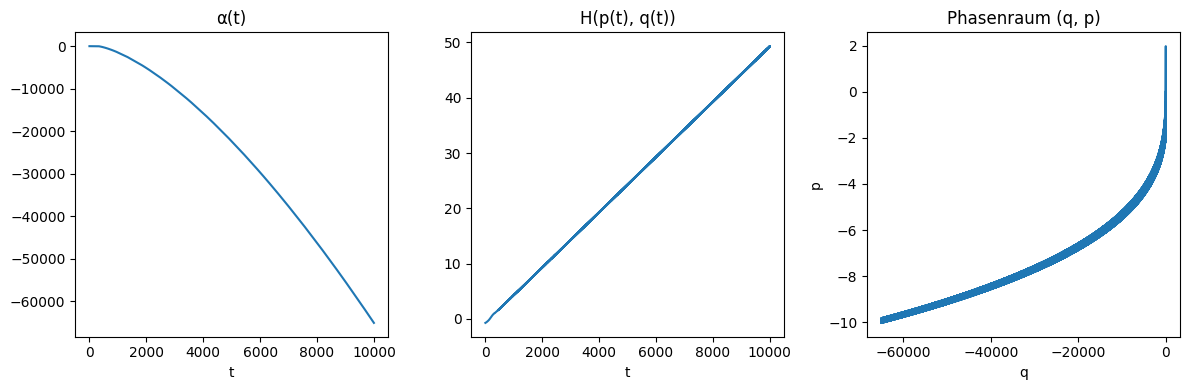

In [4]:

# Parameter
h = 0.01        # Schrittweite
T = 10000       # Endzeit
N = int(T/h)    # Anzahl Schritte
m, g, l = 1, 1, 1

# Anfangsbedingungen (45° in Radiant)
alpha = np.zeros(N+1)
omega = np.zeros(N+1)
alpha[0] = np.radians(45)
omega[0] = 0.0

# Euler-Verfahren
for n in range(N):
    alpha[n+1] = alpha[n] + h * omega[n]
    omega[n+1] = omega[n] + h * (-g/l * np.sin(alpha[n]))

# Energie H(p,q) mit p = ml²α', q = α
p = m * l**2 * omega
q = alpha
H = -m*g*l*np.cos(q) + p**2 / (2*m*l**2)

t = np.linspace(0, T, N+1)

# Plots
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(t, alpha)
plt.title("α(t)")
plt.xlabel("t")

plt.subplot(1,3,2)
plt.plot(t, H)
plt.title("H(p(t), q(t))")
plt.xlabel("t")

plt.subplot(1,3,3)
plt.plot(q, p)
plt.title("Phasenraum (q, p)")
plt.xlabel("q")
plt.ylabel("p")

plt.tight_layout()
plt.show()

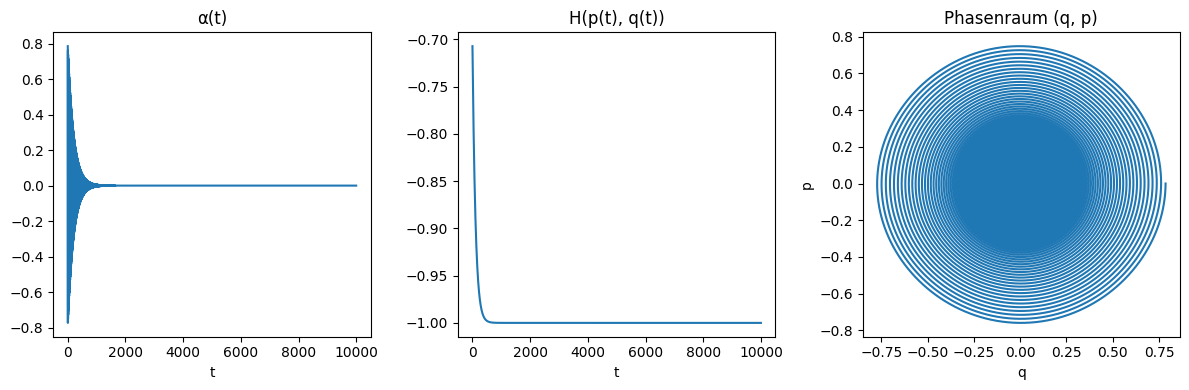

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
tau = 0.01
T = 10000
N = int(T / tau)
g, l, m = 1, 1, 1

# f(t, u) - rechte Seite
def f(u):
    alpha, omega = u
    return np.array([omega, -g/l * np.sin(alpha)])

# Jacobi-Matrix von f
def Jf(u):
    alpha, omega = u
    return np.array([
        [0, 1],
        [-g/l * np.cos(alpha), 0]
    ])

# Newton-Verfahren um u_{j+1} zu finden
def newton(u_j, t_next, tol=1e-10, max_iter=50):
    x = u_j.copy()  # Startwert
    for _ in range(max_iter):
        gx = x - u_j - tau * f(x)           # g(x)
        Jg = np.eye(2) - tau * Jf(x)        # g'(x)
        dx = np.linalg.solve(Jg, gx)        # [g'(x)]^{-1} * g(x)
        x = x - dx
        if np.linalg.norm(dx) < tol:
            break
    return x

# Anfangsbedingungen
alpha0 = np.radians(45)
omega0 = 0.0
u = np.array([alpha0, omega0])

# Speichern
alphas = [alpha0]
omegas = [omega0]

# Impliziter Euler
for j in range(N):
    t_next = (j+1) * tau
    u = newton(u, t_next)
    alphas.append(u[0])
    omegas.append(u[1])

alphas = np.array(alphas)
omegas = np.array(omegas)
t = np.linspace(0, T, N+1)

# Energie
p = m * l**2 * omegas
q = alphas
H = -m*g*l*np.cos(q) + p**2 / (2*m*l**2)

# Plots
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(t, alphas)
plt.title("α(t)")
plt.xlabel("t")

plt.subplot(1,3,2)
plt.plot(t, H)
plt.title("H(p(t), q(t))")
plt.xlabel("t")

plt.subplot(1,3,3)
plt.plot(q, p)
plt.title("Phasenraum (q, p)")
plt.xlabel("q")
plt.ylabel("p")

plt.tight_layout()
plt.show()